#Importing Libraries

In [45]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

#Data Preprocessing

#Training-Image Preprocessing 

In [46]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'dataset',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 35725 files belonging to 23 classes.


#Validation Image Preprocessing

In [50]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'dataset',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 35725 files belonging to 23 classes.


#Model Building

In [64]:
tf.keras.backend.clear_session()
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Rescaling(1./255, input_shape=(128,128,3)))

#Convolution Layer

In [65]:




cnn.add(tf.keras.layers.Conv2D(32,3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(32,3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [66]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [67]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [68]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [69]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [70]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [71]:
cnn.add(tf.keras.layers.Flatten())

In [72]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [73]:
cnn.add(tf.keras.layers.Dropout(0.4)) #Avoids Overfitting

In [74]:
cnn.add(tf.keras.layers.Dense(units=23,activation='softmax'))#Output Layer

#Compiling and Training

In [75]:
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [76]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        34,523 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,820,247 (29.83 MB)

 Trainable params: 7,820,247 (29.83 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
training_history = cnn.fit( training_set, validation_data=validation_set, epochs=5)

Epoch 1/5
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 1469s 1s/step - accuracy: 0.8592 - loss: 0.4188 - val_accuracy: 0.8826 - val_loss: 0.3507
Epoch 2/5
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 1505s 1s/step - accuracy: 0.8928 - loss: 0.3172 - val_accuracy: 0.9178 - val_loss: 0.2413
Epoch 3/5
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 1473s 1s/step - accuracy: 0.9169 - loss: 0.2478 - val_accuracy: 0.9567 - val_loss: 0.1320
Epoch 4/5
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 1887s 2s/step - accuracy: 0.9300 - loss: 0.2043 - val_accuracy: 0.9669 - val_loss: 0.1003
Epoch 5/5
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 1869s 2s/step - accuracy: 0.9452 - loss: 0.1612 - val_accuracy: 0.9707 - val_loss: 0.0870


#Evaluating Model

In [81]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training Loss, Training accuracy:', train_loss, train_acc)

1117/1117 ━━━━━━━━━━━━━━━━━━━━ 304s 272ms/step - accuracy: 0.9707 - loss: 0.0870
Training Loss, Training accuracy: 0.0870077982544899 0.9706647992134094


In [82]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation Loss, Validation accuracy:', val_loss, val_acc)

1117/1117 ━━━━━━━━━━━━━━━━━━━━ 341s 305ms/step - accuracy: 0.9707 - loss: 0.0870
Validation Loss, Validation accuracy: 0.08700771629810333 0.9706647992134094


#Saving Model

In [83]:
cnn.save('trained_plant_disease_model.keras')

In [84]:
 #Return the Dictionary of history
training_history.history

{'accuracy': [0.8591742515563965,
  0.8928201794624329,
  0.9168649315834045,
  0.9299929738044739,
  0.945220410823822],
 'loss': [0.41884511709213257,
  0.31719279289245605,
  0.24784472584724426,
  0.2043144553899765,
  0.16122184693813324],
 'val_accuracy': [0.8826032280921936,
  0.9178166389465332,
  0.9566689729690552,
  0.9669418931007385,
  0.9706647992134094],
 'val_loss': [0.35071811079978943,
  0.24132905900478363,
  0.13202889263629913,
  0.10027056932449341,
  0.08700776100158691]}

In [85]:
#Recording the History in json format
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [86]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


#Accuracy Visualization

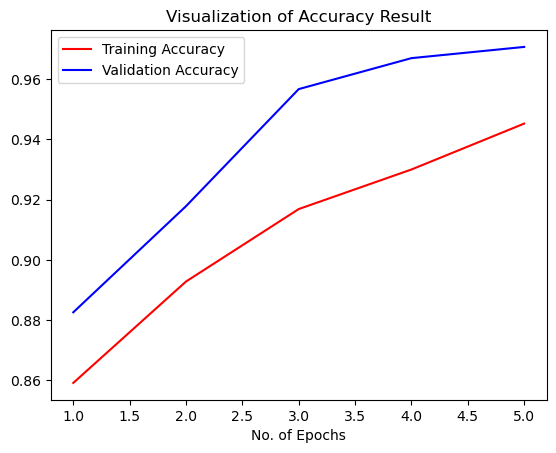

In [90]:
epochs = [i for i in range(1,6)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

#Model Evaluation using Precision, Recall and F1 Score

In [92]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [96]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'Dataset',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 35725 files belonging to 23 classes.


In [97]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

35725/35725 ━━━━━━━━━━━━━━━━━━━━ 1048s 29ms/step


In [104]:
predicted_categories

<tf.Tensor: shape=(35725,), dtype=int64, numpy=array([ 0,  0,  0, ..., 22, 22, 22], shape=(35725,))>

In [105]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [106]:
Y_true

<tf.Tensor: shape=(35725,), dtype=int64, numpy=array([ 0,  0,  0, ..., 22, 22, 22], shape=(35725,))>

In [107]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [108]:
# Precision Recall F1_score
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.96      0.97      2016
                                 Apple___Black_rot       0.98      1.00      0.99      1987
                          Apple___Cedar_apple_rust       0.98      0.99      0.99      1760
                                   Apple___healthy       0.96      0.99      0.97      2008
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.94      0.95      1642
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00      1907
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.98      0.97      1908
                            Corn_(maize)___healthy       1.00      1.00      1.00      1859
                     Pepper__bell___Bacterial_spot       0.99      0.90      0.94       997
                            Pepper__bell___healthy       0.99      0.97      0.

#Visualizing Confusion Matrix

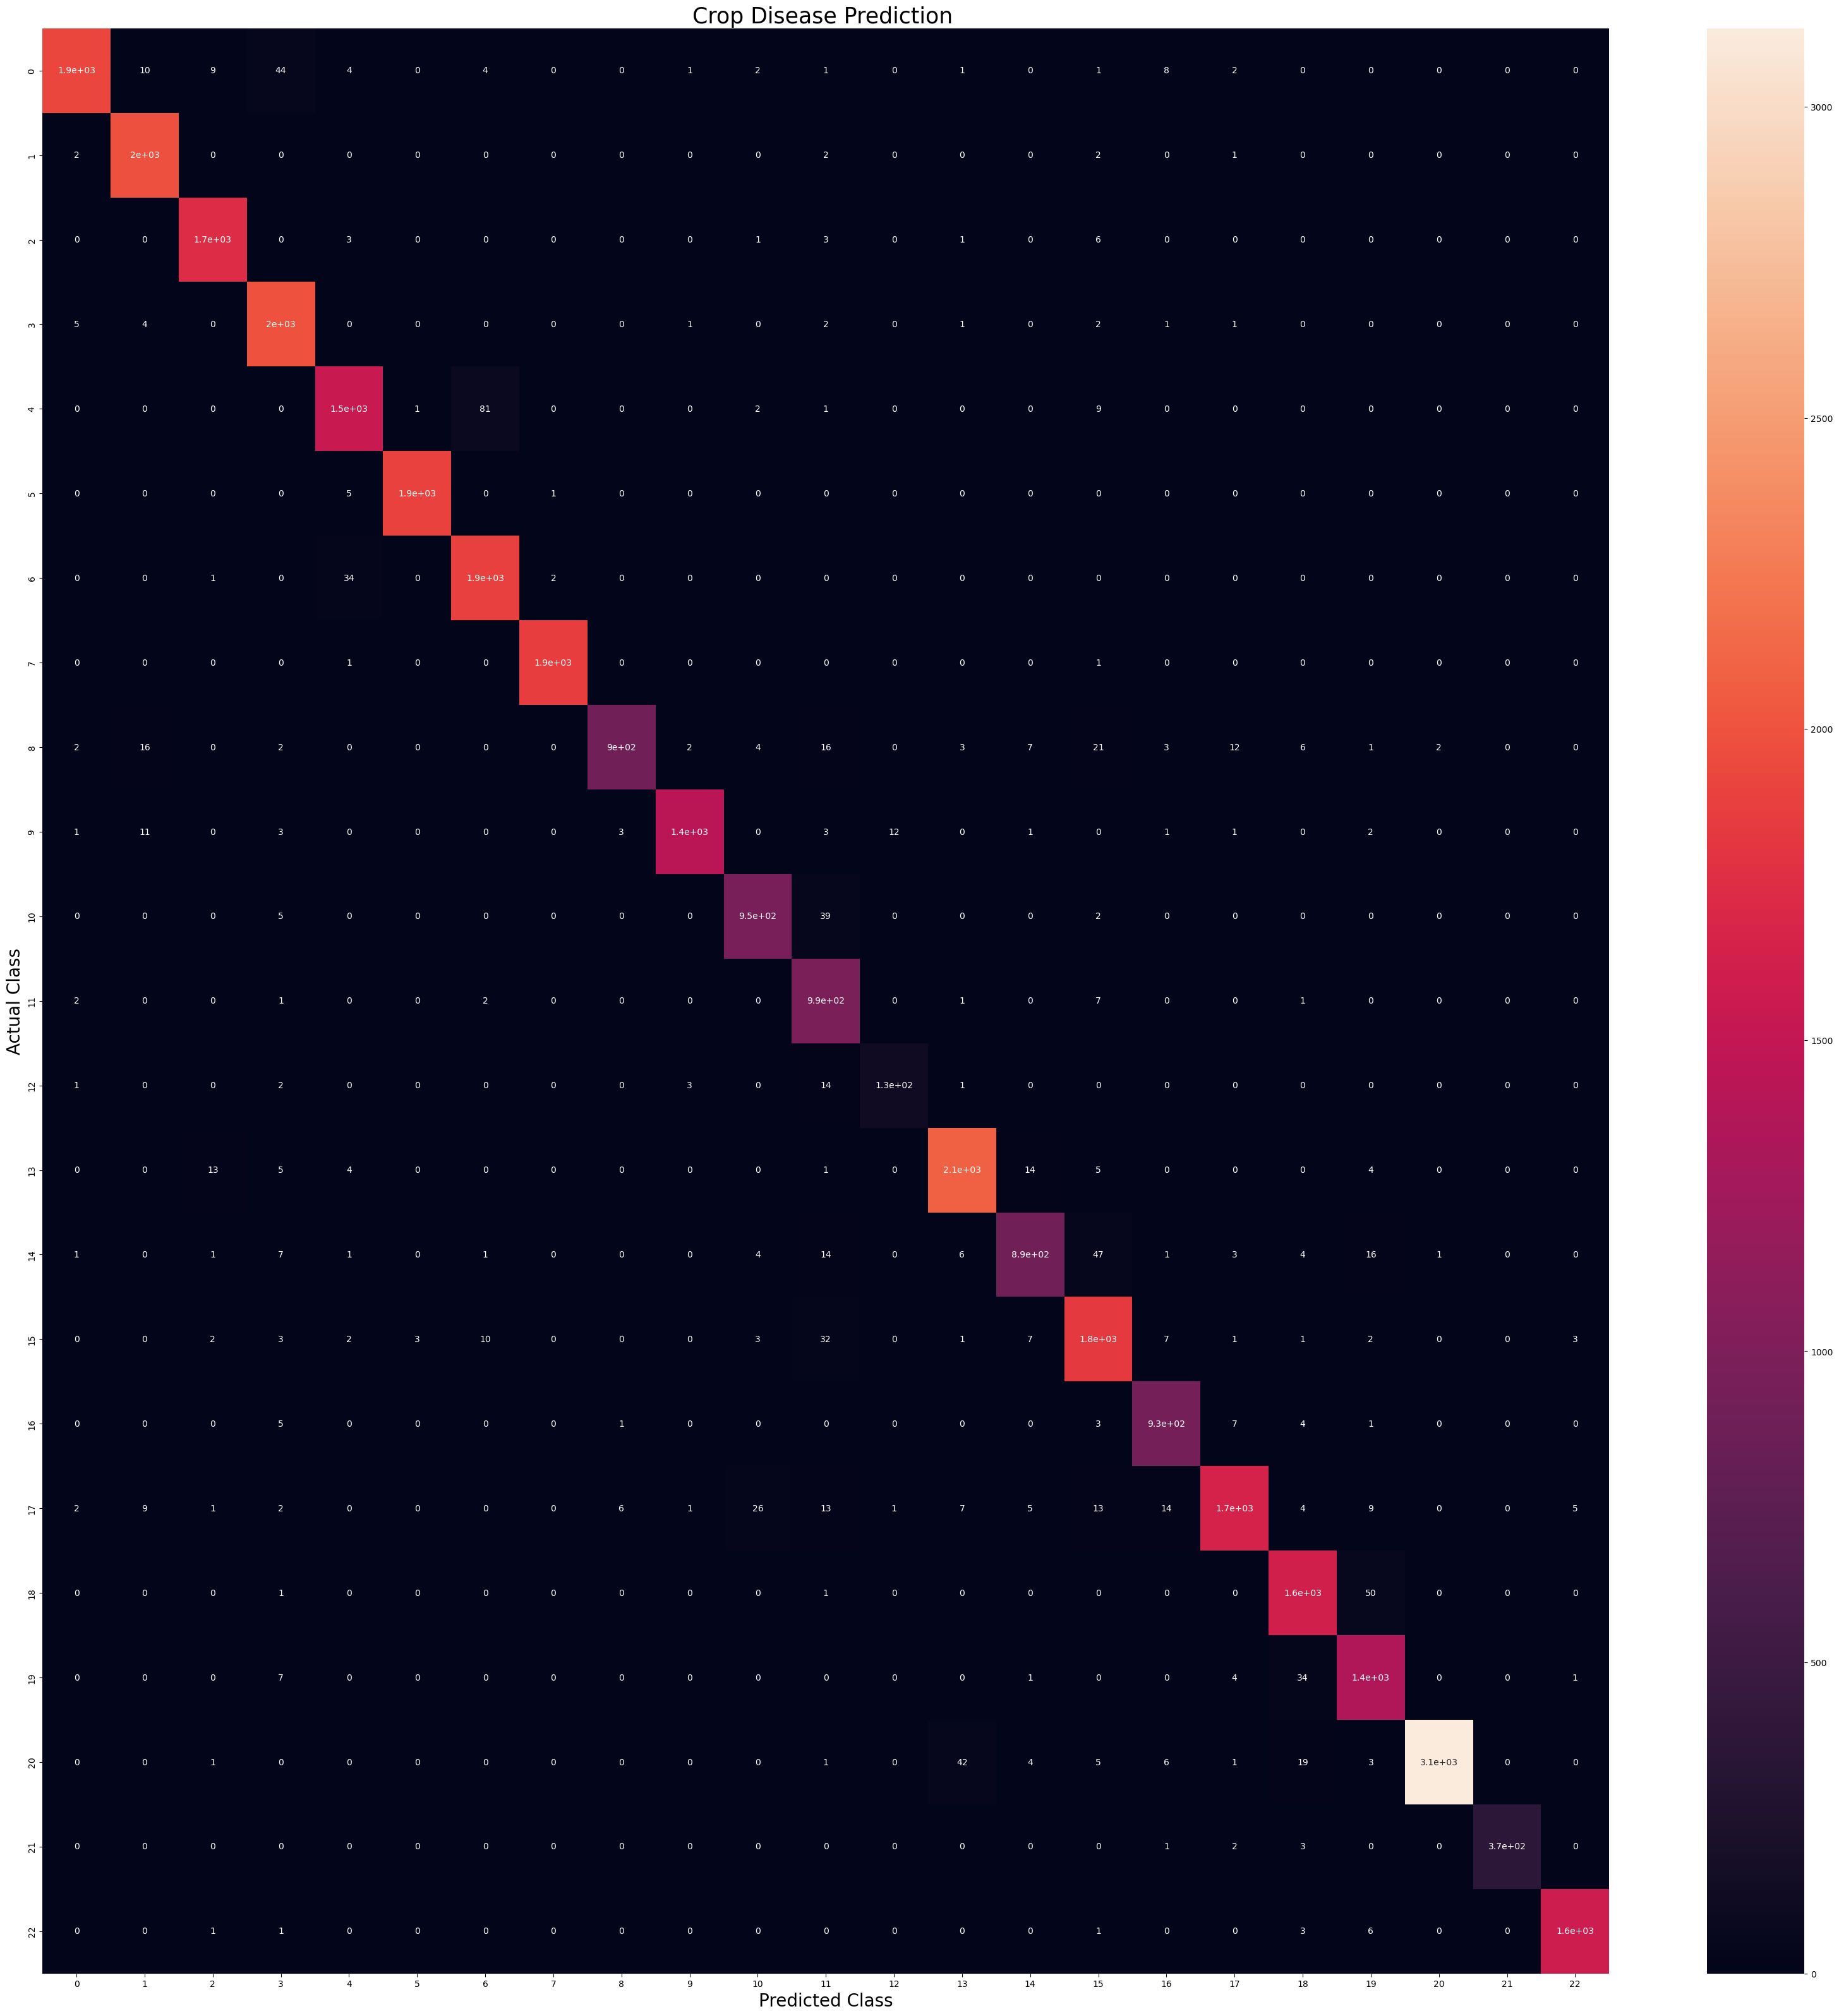

In [114]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Crop Disease Prediction ',fontsize = 25)
plt.show()